In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from matplotlib.patches import Ellipse

In [103]:
ov = pd.read_csv(r"C:\Users\s4770224\Documents\Work\Writing\Figures\Obj2\overview.csv")
ov["set"] = ov["dataset"] + ov["Sensor"]
params = {
    "marker" : {
        'tests2': "skyblue", 
        'valis2': "navy", 
        'testpsd' : "lightcoral", 
        'valipsd' : "red", 
        'testenm' : 'lightgreen', 
        'valienm' : "darkgreen"
    },
    "symbol" : {
        "bo" : "o",
        "kbrgm" : "x", 
        "class" : "v"
    },
    "colour" : {
        's2': "skyblue", 
        'psd' : "lightcoral", 
        'enm' : 'lightgreen', 
        },
    "size" : {
        "test" : 10, 
        "vali" : 20,
    }
}

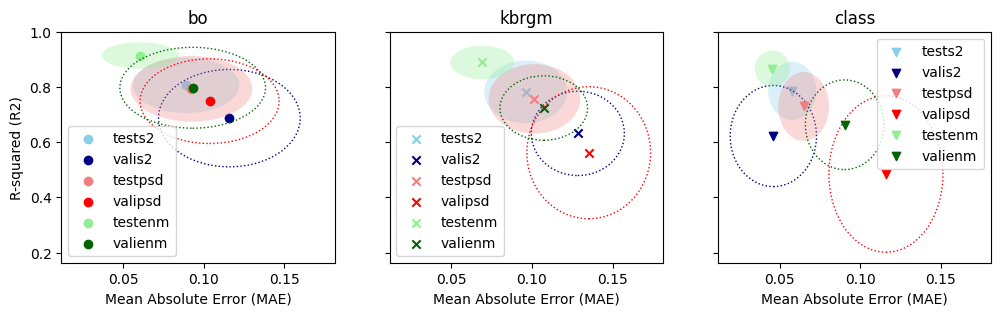

In [134]:
fig, ax = plt.subplots(1, 3, figsize = (12, 3), sharex = True, sharey = True)

for number, scheme in enumerate(ov["scheme"].unique()) : 
    df = ov[ov["scheme"] == scheme]
    x=df["MAE"]
    y=df["R2"]
    x_err=df["std MAE"]
    y_err=df["std R2"]
    c = [params["marker"].get(x) for x in df["set"]]
    markers = [params["symbol"].get(x) for x in df["scheme"]]
    
    for i in range(df.shape[0]):
        if df["dataset"].iloc[i] == "test":
            is_filled = True
        else:
            is_filled = False
        
        ellipse = Ellipse(
                xy=(x.iloc[i], y.iloc[i]),
                width=2 * x_err.iloc[i],
                height=2 * y_err.iloc[i],
                facecolor=c[i] if is_filled else "none",
                edgecolor = c[i], #params["colour"].get(df["Sensor"].iloc[i]),
                alpha= 0.3 if is_filled else 1.0,
                linewidth=0 if is_filled else 1,
                linestyle = ":" if not is_filled else " "
            )
        ax[number].add_patch(ellipse)
    
        ax[number].scatter(x.iloc[i], y.iloc[i], c = c[i], marker = params["symbol"].get(df["scheme"].iloc[i]), label = df["set"].iloc[i])
        ax[number].legend()
        ax[number].set_xlabel("Mean Absolute Error (MAE)")
        ax[number].set_title(scheme)
        
ax[0].set_ylabel("R-squared (R2)")
plt.savefig(r"C:\Users\s4770224\Documents\Work\Writing\Figures\Obj2\overview.svg", dpi = 300)
plt.show()